In [1]:
# 1. Настройка автоперезагрузки модулей (удобно при разработке)
%load_ext autoreload
%autoreload 2

# 2. Импорт конфигов
import config as cnfg
import config_paths as cnfg_p

# 3. Проверка и создание папок (если их нет)
# При первом запуске он создаст папки data/raw, data/processed и т.д.
cnfg_p.init_structure()

# 4. Библиотечные импорты
import matplotlib.pyplot as plt
import pandas as pd

# 5. Импорт ваших расчетных модулей
from scripts import import_data as idt
from scripts import data_manager as dm
from scripts import plot_manager as pm
# from scripts import pressure_predictor as ppm
from scripts.independent_linear_predictor import pressure_predictor_lite as prm
from scripts.independent_linear_predictor import model_optimizator as opt

--- Проверка структуры проекта ---
[OK] data\raw
[OK] data\processed
[OK] data\config
[OK] gui
----------------------------------



In [2]:
# # Ячейка 3: Запуск обработки
# df_logs, df_registry = idt.run_extraction(
#     raw_dir=cnfg_p.RAW_DATA_DIR,
#     logs_file=cnfg_p.LOGS_FILE,
#     reg_file=cnfg_p.REGISTRY_FILE,
#     settings=cnfg.EXTRACTION_SETTINGS,
#     col_config=cnfg.COLUMNS_CONFIG
# )

In [3]:
df_logs = dm.load_database(cnfg_p.LOGS_FILE)
df_registry = dm.load_database(cnfg_p.REGISTRY_FILE)
df_reference_setpoint = dm.load_database(cnfg_p.REFERENCE_SETPOINT_FILE)

Загрузка: cycles_logs.csv
Загрузка: cycles_registry.csv
Загрузка: ТК.20-500.895.1-7.4. ред.0 (настроечные параметры дезоксидации).csv


In [4]:
dm.show_columns_list(df_registry)


--- Список полей ---
"LD11C1\Process Data.BarDiameter (Диаметр заготовки)",
"LD31W.Weigh P1 - вес в баке",
"CtpOut002_Shell_length (Длина гильзы)",
"CtpOut056_Plug_bar_diameter (Диаметр оправки)",
"63: Tube diameter at FQT outlet",
"IBA_DB\PT1009 Актуальное давление в баке P1 (бар)",
"IBA_DB\PT1014 Актуальное давление в трубе (бар)",
"LD31W.VALVE 1007 - клапан бака, бар",
"LD31W.VALVE 1008 - клапан трубы, бар",
"cycle_id",
"cycle_start_time",
"duration",


Text(0.5, 1.0, 'Зависимость управляющего сигнала от давления в баке P1 для всех продувок')

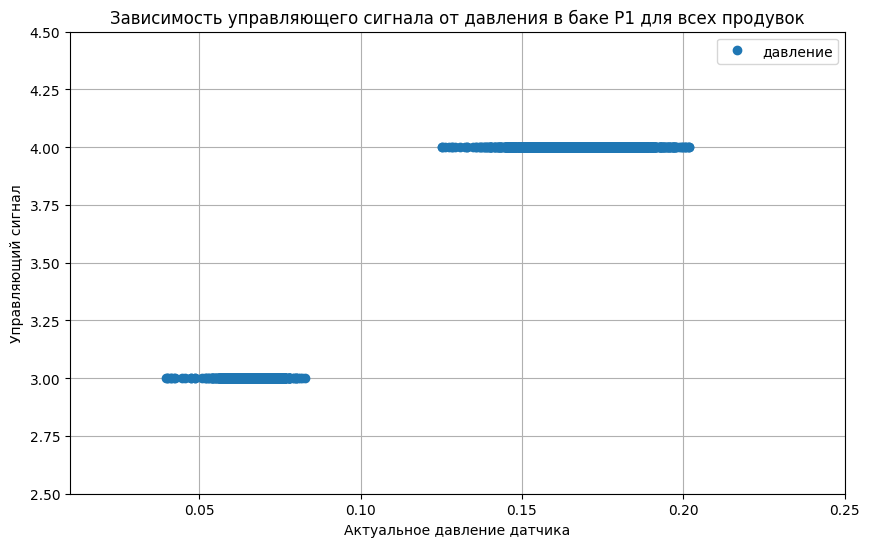

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(df_registry['IBA_DB\PT1009 Актуальное давление в баке P1 (бар)'], 
         df_registry['LD31W.VALVE 1007 - клапан бака, бар']*10, 'o', label='давление')
plt.xlabel('Актуальное давление датчика')
plt.ylabel('Управляющий сигнал')
plt.ylim(2.5, 4.5)
plt.xlim(0.01, 0.25) # Подстройте по вашим данным
plt.legend()
plt.grid()
plt.title('Зависимость управляющего сигнала от давления в баке P1 для всех продувок')

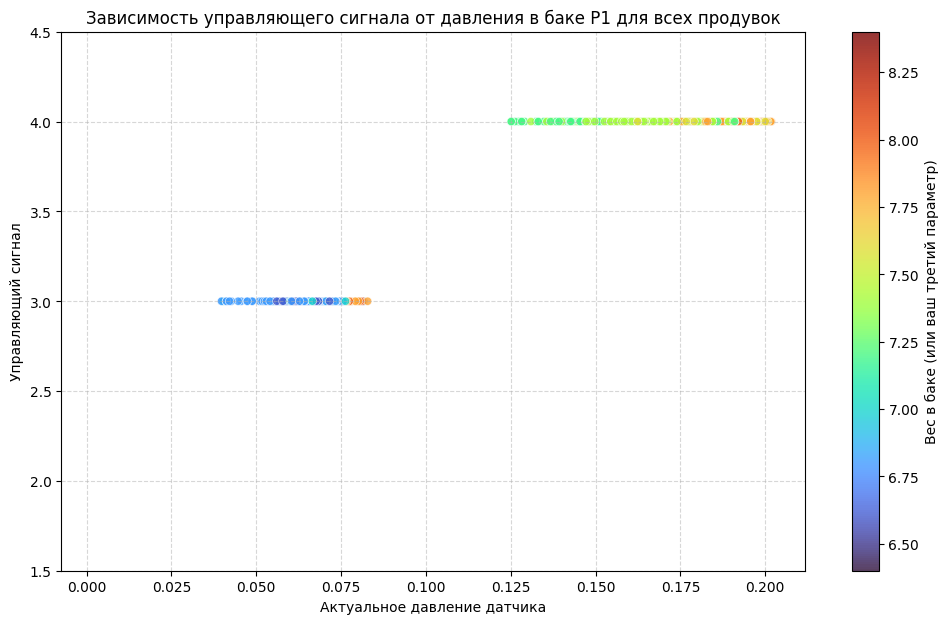

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# 1. Выберите третий параметр для раскраски точек (например, вес в баке)
# color_by = df_registry['LD31W.Weigh P1 - вес в баке']
color_by = df_registry["duration"]

# 2. Используем scatter вместо plot
sc = plt.scatter(
    df_registry['IBA_DB\PT1009 Актуальное давление в баке P1 (бар)'], 
    df_registry['LD31W.VALVE 1007 - клапан бака, бар'] * 10, 
    c=color_by,           # Параметр для раскраски
    cmap='turbo',       # Цветовая карта (например: 'viridis', 'plasma', 'coolwarm', 'jet')
    alpha=0.8,            # Небольшая прозрачность, чтобы видеть наложение точек
    edgecolors='w',       # Белая тонкая обводка точек, чтобы они не сливались
    linewidths=0.5
)

plt.xlabel('Актуальное давление датчика')
plt.ylabel('Управляющий сигнал')
plt.ylim(1.5, 4.5)
# plt.xlim(0.025, 0.1) # Подстройте по вашим данным
# plt.xlim(0.1, 0.2) # Подстройте по вашим данным

# 3. Добавляем цветовую шкалу справа, чтобы понимать, какому цвету какое значение соответствует
cbar = plt.colorbar(sc)
cbar.set_label('Вес в баке (или ваш третий параметр)') # Подпись к цветовой шкале

plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Зависимость управляющего сигнала от давления в баке P1 для всех продувок')
plt.show()

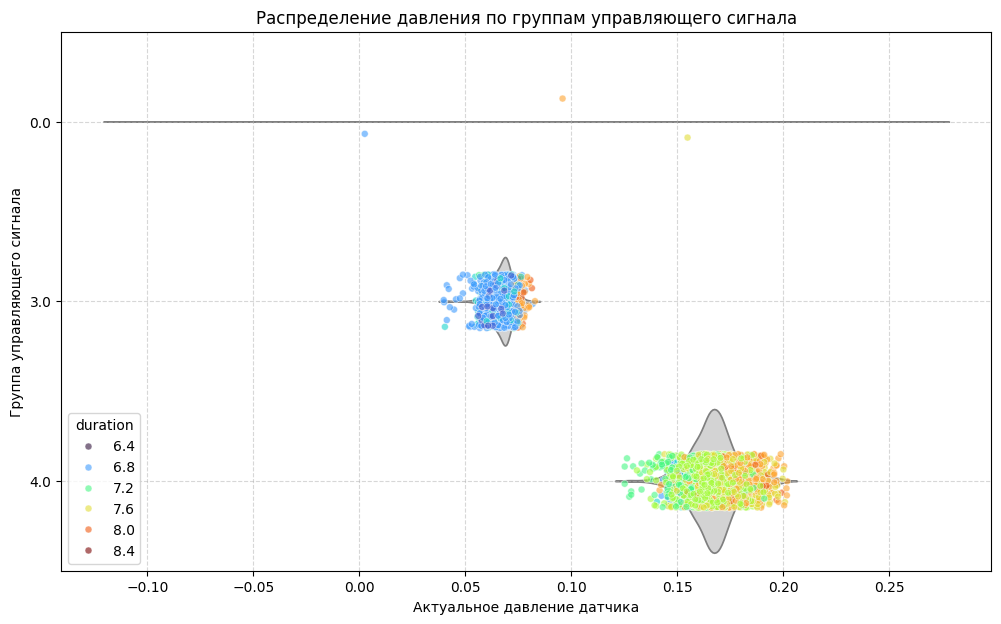

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Округлим управляющий сигнал для группировки (например, до целых или до 1 знака)
df_registry['signal_group'] = (df_registry['LD31W.VALVE 1007 - клапан бака, бар'] * 10).round(1)

# Строим "скрипки", которые показывают форму распределения (плотность)
sns.violinplot(
    data=df_registry,
    x='IBA_DB\PT1009 Актуальное давление в баке P1 (бар)',
    y='signal_group',
    orient='h',          # Горизонтальная ориентация
    color='lightgray',   # Нейтральный фон для скрипки
    inner=None,          # Убираем внутренние маркеры скрипки
    density_norm='count' # Пропорционально количеству точек
)

# Накладываем сверху ваши цветные точки с небольшим шумом (стрипплот)
sns.stripplot(
    data=df_registry,
    x='IBA_DB\PT1009 Актуальное давление в баке P1 (бар)',
    y='signal_group',
    hue='duration',      # Раскраска по третьему параметру
    palette='turbo',
    alpha=0.6,
    jitter=0.15,         # Степень случайного рассеяния точек по вертикали
    orient='h',
    edgecolor='white',
    linewidth=0.5,
    size=5
)

plt.xlabel('Актуальное давление датчика')
plt.ylabel('Группа управляющего сигнала')
plt.title('Распределение давления по группам управляющего сигнала')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

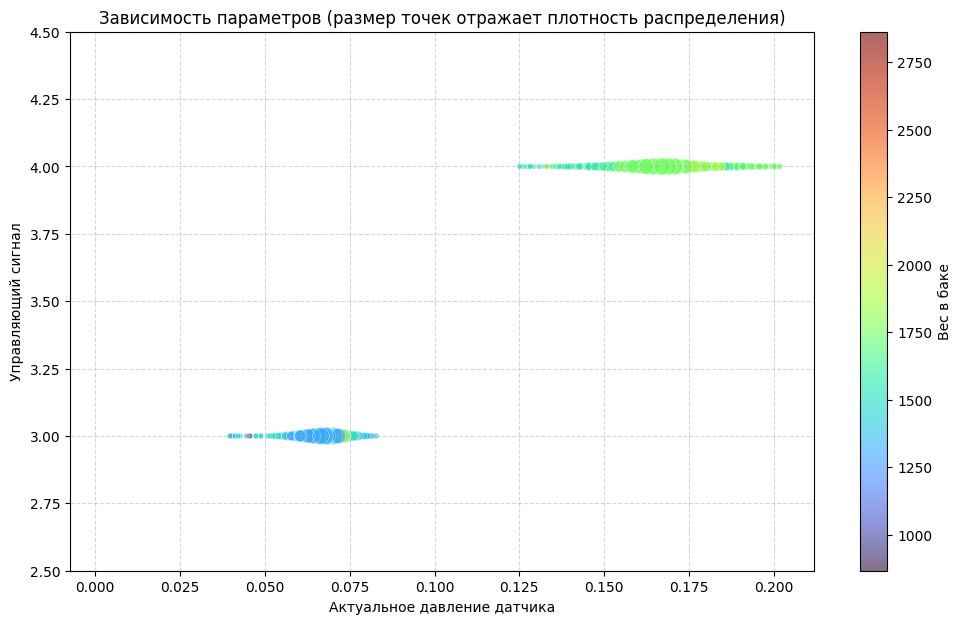

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

plt.figure(figsize=(12, 7))

x = df_registry['IBA_DB\PT1009 Актуальное давление в баке P1 (бар)']
y = df_registry['LD31W.VALVE 1007 - клапан бака, бар'] * 10
# color_by = df_registry["duration"]
color_by = df_registry["LD31W.Weigh P1 - вес в баке"]

# Вычисляем плотность точек на плоскости
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# Нормализуем плотность, чтобы задать размер точек (например, от 15 до 150)
sizes = 15 + 135 * (z - z.min()) / (z.max() - z.min())

sc = plt.scatter(
    x, 
    y, 
    c=color_by,           
    s=sizes,            # Размер зависит от плотности распределения
    cmap='turbo',       
    alpha=0.6,            
    edgecolors='w',       
    linewidths=0.5
)

plt.xlabel('Актуальное давление датчика')
plt.ylabel('Управляющий сигнал')
plt.ylim(2.5, 4.5)

cbar = plt.colorbar(sc)
cbar.set_label('Вес в баке')
# cbar.set_label('Время цикла')

plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Зависимость параметров (размер точек отражает плотность распределения)')
plt.show()

In [7]:
df_reference_setpoint = df_reference_setpoint.astype({'Dia_Shell': int, 'L_Shell': int})
dm.show_columns_list(df_reference_setpoint)


--- Список полей ---
"Dia_Shell",
"L_Shell",
"Q_deoxidation",
"Time_cycle",
"First_cycle",
"p_tank_preset_1",
"p_tank_preset_2",
"p_tank_preset_3",
"p_tank_preset_4",
"p_tank_preset_5",
"p_tank_preset_6",
"p_tank_preset_7",
"p_tank_preset_8",
"p_tank_preset_9",
"p_tank_preset_10",
"p_pipe_preset_1",
"p_pipe_preset_2",
"p_pipe_preset_3",
"p_pipe_preset_4",
"p_pipe_preset_5",
"p_pipe_preset_6",
"p_pipe_preset_7",
"p_pipe_preset_8",
"p_pipe_preset_9",
"p_pipe_preset_10",


In [8]:
df_registry = idt.classify_registry_generic(df_registry, cnfg.CLASSIFICATION_TASKS)

[Classify] Создана колонка 'Dia_Shell' на основе 'LD11C1\Process Data.BarDiameter (Диаметр заготовки)'
[Classify] Создана колонка 'L_Shell' на основе 'CtpOut002_Shell_length (Длина гильзы)'


In [9]:
# dm.save_database(df_logs, cnfg_p.LOGS_FILE)
# dm.save_database(df_registry, cnfg_p.REGISTRY_FILE)
# dm.save_database(df_reference_setpoint, cnfg_p.REFERENCE_SETPOINT_FILE)

In [10]:
group_cols = ["Dia_Shell", "L_Shell"]
detailed_cols = [
    "IBA_DB\PT1014 Актуальное давление в трубе (бар)",
    "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)",
    "IBA_DB\PT1010 Актуальное давление в спирали (бар)",
    "LD31W.Weigh P1 - вес в баке",  
    "LD31W.Vessel.PT1009 - давление баке",
    "LD31W.VALVE 1007 - клапан бака, бар",
    "LD31W.VALVE 1008 - клапан трубы, бар",
    "X1213_CLS - клапан порошка закр", 
]
df_avg_logs, df_avg_registry = dm.get_averaged_profiles(
    df_logs, 
    df_registry, 
    cnfg.CLASSIFICATION_TASKS, 
    detailed_cols)


In [11]:
df_avg_logs = df_avg_logs.astype({'Dia_Shell': int, 'L_Shell': int})
df_avg_registry = df_avg_registry.astype({'Dia_Shell': int, 'L_Shell': int})

In [12]:
df_avg_logs = dm.apply_target_logic(
    df_avg_logs, 
    df_avg_registry, 
    df_reference_setpoint, 
    cnfg.CONFIG_GENERATE_TARGET_TANK
    )
df_avg_logs = dm.apply_target_logic(
    df_avg_logs, 
    df_avg_registry, 
    df_reference_setpoint, 
    cnfg.CONFIG_GENERATE_TARGET_PIPE
    )
# dm.save_database(df_avg_logs, cnfg_p.LOGS_AVG_FILE)
# dm.save_database(df_avg_registry, cnfg_p.REGISTRY_AVG_FILE)

In [13]:
cnfg_params, flat_params = dm.load_config(cnfg_p.DEFAULT_MODEL_PARAMS_TANK_FILE)

In [14]:
df_avg_logs, df_avg_registry = prm.apply_analytic_model(
    df_avg_logs, 
    df_avg_registry,
    cnfg.CONFIG_PREDICTOR_TANK, 
    flat_params
    )

In [15]:
cycle_ids = [
    "AVG_D_273_L_7000",
    "AVG_D_273_L_9000",
    "AVG_D_273_L_10000",
    "AVG_D_182_L_8000",
    "AVG_D_182_L_5000",
    "AVG_D_273_L_8000"    
]

# df_avg_logs, df_avg_registry = dm.remove_cycles_from_data(df_avg_logs, df_avg_registry, cycle_ids, col_cycle='cycle_id')

In [16]:
dm.save_database(df_avg_logs, cnfg_p.LOGS_AVG_FILE)
dm.save_database(df_avg_registry, cnfg_p.REGISTRY_AVG_FILE)

In [17]:
dm.show_columns_list(df_avg_registry)


--- Список полей ---
"Dia_Shell",
"L_Shell",
"63: Tube diameter at FQT outlet",
"CtpOut002_Shell_length (Длина гильзы)",
"CtpOut056_Plug_bar_diameter (Диаметр оправки)",
"IBA_DB\PT1009 Актуальное давление в баке P1 (бар)",
"IBA_DB\PT1014 Актуальное давление в трубе (бар)",
"LD11C1\Process Data.BarDiameter (Диаметр заготовки)",
"LD31W.VALVE 1007 - клапан бака, бар",
"LD31W.VALVE 1008 - клапан трубы, бар",
"LD31W.Weigh P1 - вес в баке",
"duration",
"n_samples",
"cycle_id",
"MAE_tank",


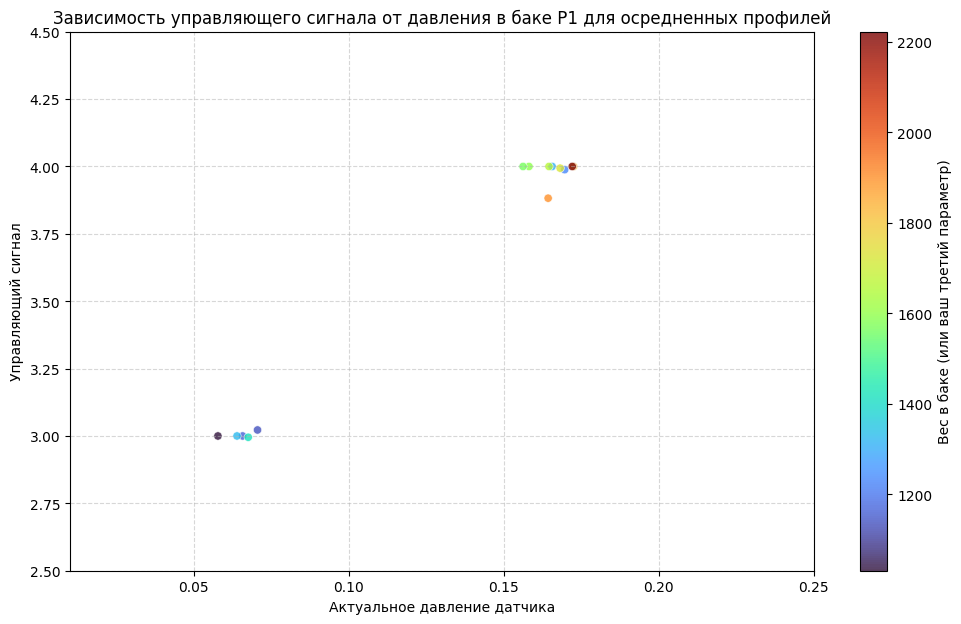

In [18]:
plt.figure(figsize=(12, 7))

# 1. Выберите третий параметр для раскраски точек (например, вес в баке)
color_by = df_avg_registry["LD31W.Weigh P1 - вес в баке"]
# color_by = df_avg_registry["duration"]

# 2. Используем scatter вместо plot
sc = plt.scatter(
    df_avg_registry['IBA_DB\PT1009 Актуальное давление в баке P1 (бар)'], 
    df_avg_registry['LD31W.VALVE 1007 - клапан бака, бар'] * 10, 
    c=color_by,           # Параметр для раскраски
    cmap='turbo',       # Цветовая карта (например: 'viridis', 'plasma', 'coolwarm', 'jet')
    alpha=0.8,            # Небольшая прозрачность, чтобы видеть наложение точек
    edgecolors='w',       # Белая тонкая обводка точек, чтобы они не сливались
    linewidths=0.5
)

plt.xlabel('Актуальное давление датчика')
plt.ylabel('Управляющий сигнал')
plt.ylim(2.5, 4.5)
plt.xlim(0.01, 0.25) # Подстройте по вашим данным
# plt.xlim(0.1, 0.2) # Подстройте по вашим данным

# 3. Добавляем цветовую шкалу справа, чтобы понимать, какому цвету какое значение соответствует
cbar = plt.colorbar(sc)
cbar.set_label('Вес в баке (или ваш третий параметр)') # Подпись к цветовой шкале

plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Зависимость управляющего сигнала от давления в баке P1 для осредненных профилей')

plt.show()

*Алгоритм оптимизации 

In [19]:
params_to_tune = ["dead_time", "k_gain", "b_gain", "damping"]

best_params, raw_result = opt.run_universal_optimizer(
    df_avg_logs, 
    df_avg_registry, 
    cnfg_params,
    # cnfg.CONFIG_PREDICTOR_TANK, 
    cnfg.CONFIG_PREDICTOR_PIPE, 
    params_to_tune
)

# best_params теперь содержит что-то вроде:
# {'dead_time': 0.12, 'k_gain': 0.035, 'b_gain': 0.015, 'damping': 0.42}

--- ОПТИМИЗАЦИЯ ПАРАМЕТРОВ: ['dead_time', 'k_gain', 'b_gain', 'damping'] ---
 Шаг: 1.1%, MAE: 0.02880
 Шаг: 1.5%, MAE: 0.02292
 Шаг: 1.9%, MAE: 0.02137
 Шаг: 1.9%, MAE: 0.02137
 Шаг: 2.0%, MAE: 0.02033
 Шаг: 2.2%, MAE: 0.02033
 Шаг: 2.8%, MAE: 0.02033
 Шаг: 3.1%, MAE: 0.02033
 Шаг: 3.4%, MAE: 0.02033
 Шаг: 3.5%, MAE: 0.02031
 Шаг: 5.5%, MAE: 0.02031
 Шаг: 6.1%, MAE: 0.02031
 Шаг: 6.1%, MAE: 0.02004
 Шаг: 7.0%, MAE: 0.01996
 Шаг: 7.8%, MAE: 0.01996
 Шаг: 13.8%, MAE: 0.01996
 Шаг: 20.2%, MAE: 0.01989
 Шаг: 19.9%, MAE: 0.01986
 Шаг: 20.8%, MAE: 0.01986
 Шаг: 32.0%, MAE: 0.01986
 Шаг: 45.7%, MAE: 0.01986
 Шаг: 63.3%, MAE: 0.01982
 Шаг: 69.5%, MAE: 0.01981
 Шаг: 83.9%, MAE: 0.01981
 Шаг: 106.5%, MAE: 0.01977

📋 ДЕТАЛЬНЫЙ ОТЧЕТ ОБ ОПТИМИЗАЦИИ
Статус оптимизации:       ✅ УСПЕШНО
Причина остановки:        Optimization terminated successfully.
Общее время:              132.82 сек
-------------------------------------------------------
Лучшее MAE (ошибка):      0.019768 бар
Кол-во поколений:    

In [20]:
dm.save_config(best_params, cnfg_p.CONFIG_DIR / "Optimal_model_params_pipe_4_7.json")

Конфигурация сохранена: Optimal_model_params_pipe_4_7.json


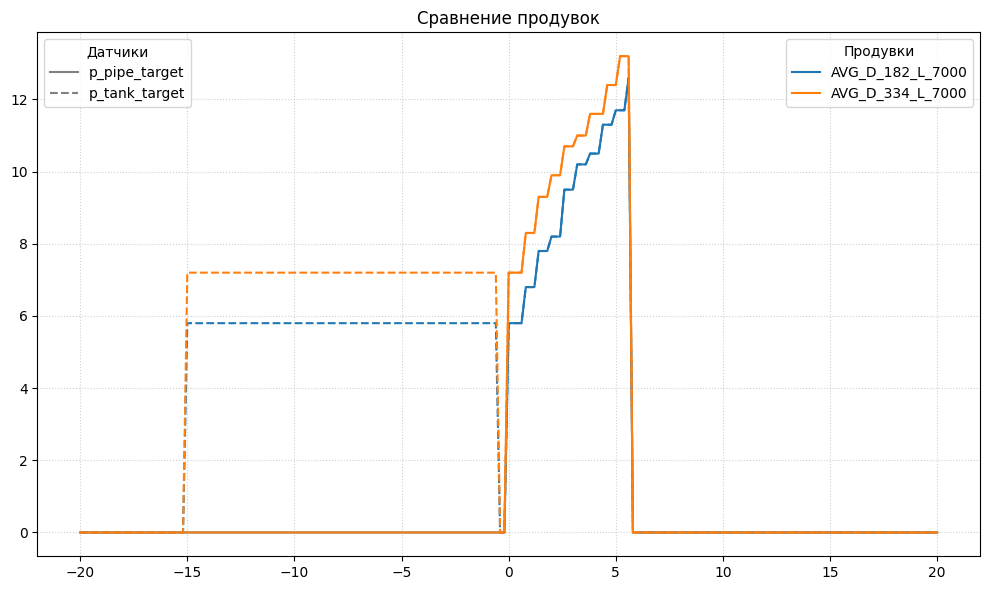

In [21]:
%matplotlib inline
# %matplotlib widget
identifiers = [
    # "AVG_D_182_L_6000",
    "AVG_D_182_L_7000",
    # "AVG_D_182_L_9000",
    # "AVG_D_182_L_10000",
    # "AVG_D_273_L_8000", 
    # "AVG_D_273_L_10000", 
    # "AVG_D_273_L_11300",
    "AVG_D_334_L_7000",
    # "AVG_D_334_L_8000"
    ]
sensors = [
    # "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)",
    # "LD31W.VALVE 1007 - клапан бака, бар",
    # "IBA_DB\PT1014 Актуальное давление в трубе (бар)",

    # "LD31W.VALVE 1007 - клапан бака, бар_median",   
    # "LD31W.VALVE 1008 - клапан трубы, бар"
    # 'p_tank_theory',
    "p_pipe_target",
    # 'p_residual_error',
    'p_tank_target',
    # "p_cycle_mae"
    # "LD31W.Weigh P1 - вес в баке"
 ]
pm.plot_cycles(df_avg_logs, df_avg_registry, identifiers, sensors)
# plt.xlim(-18, 20)
# plt.xlim(-18, 20)
# plt.ylim(-0.05, 0.6)
# plt.plot(result_df['t_relative'], result_df['p_tank_theory'], label='Модельное давление в баке', color='orange')

In [22]:
dm.show_columns_list(df_avg_logs)
dm.show_columns_list(df_avg_registry)


--- Список полей ---
"Dia_Shell",
"L_Shell",
"t_relative",
"Curve_cycle_1",
"Curve_cycle_2",
"Curve_cycle_3",
"Curve_cycle_4",
"Curve_cycle_5",
"Curve_cycle_6",
"Curve_cycle_7",
"Curve_cycle_8",
"Curve_cycle_9",
"DB_Internal\Cmd_PUY1019 - давление в спирали",
"IBA_DB\PT1009 Актуальное давление в баке P1 (бар)",
"IBA_DB\PT1009 Актуальное давление в баке P1 (бар)_median",
"IBA_DB\PT1009 Актуальное давление в баке P1 (бар)_std",
"IBA_DB\PT1010 Актуальное давление в спирали (бар)",
"IBA_DB\PT1010 Актуальное давление в спирали (бар)_median",
"IBA_DB\PT1010 Актуальное давление в спирали (бар)_std",
"IBA_DB\PT1014 Актуальное давление в трубе (бар)",
"IBA_DB\PT1014 Актуальное давление в трубе (бар)_median",
"IBA_DB\PT1014 Актуальное давление в трубе (бар)_std",
"LD31W.Spray.PT1014 - давление трубе",
"LD31W.VALVE 1007 - клапан бака, бар",
"LD31W.VALVE 1007 - клапан бака, бар_median",
"LD31W.VALVE 1007 - клапан бака, бар_std",
"LD31W.VALVE 1008 - клапан трубы, бар",
"LD31W.VALVE 1008 - клапан т

In [23]:
dm.get_summary(df_avg_registry, only_labeled=False)

,cycle_id,duration,Dia_Shell,L_Shell,n_samples
0,AVG_D_182_L_10000,7.426748,182,10000,329
1,AVG_D_182_L_6000,6.800000,182,6000,3
2,AVG_D_182_L_7000,6.853503,182,7000,314
3,AVG_D_182_L_8000,6.911245,182,8000,498
4,AVG_D_182_L_9000,7.235503,182,9000,169
5,AVG_D_273_L_10000,7.730753,273,10000,465
6,AVG_D_273_L_11300,7.705882,273,11300,34
7,AVG_D_273_L_6000,6.725581,273,6000,43
8,AVG_D_273_L_7000,6.966296,273,7000,629
9,AVG_D_273_L_8000,7.227551,273,8000,196


(-0.05, 0.6)

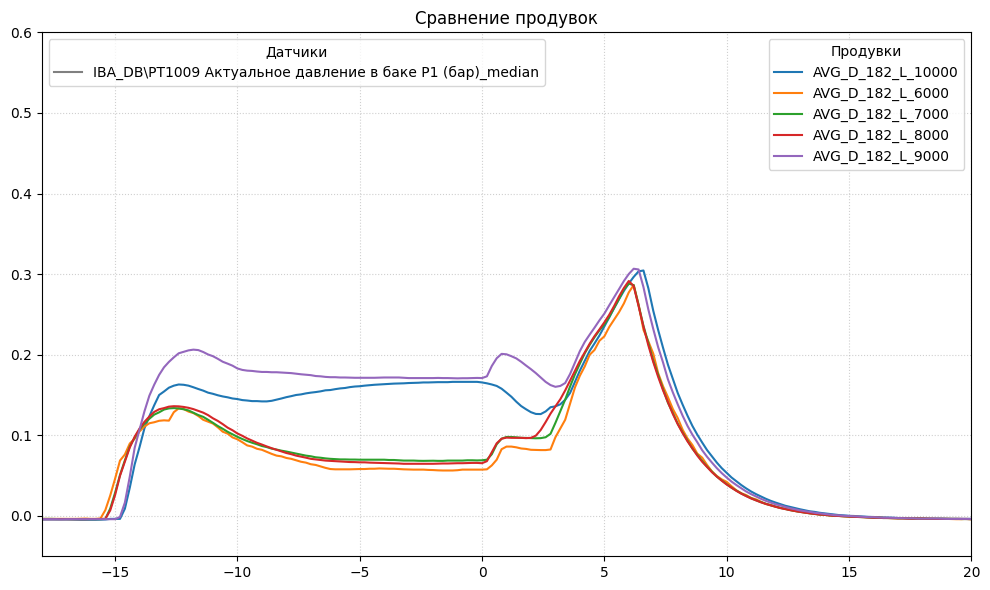

In [24]:
%matplotlib inline
# %matplotlib widget
identifiers = [
    "AVG_D_182_L_5000",
    "AVG_D_182_L_6000",
    "AVG_D_182_L_7000",
    "AVG_D_182_L_8000",
    "AVG_D_182_L_9000",
    "AVG_D_182_L_10000", 
    ]
# identifiers = [
#     "AVG_D_273_L_6000",
#     "AVG_D_273_L_7000",
#     "AVG_D_273_L_8000",
#     "AVG_D_273_L_9000",
#     "AVG_D_273_L_10000",
#     "AVG_D_273_L_11300", 
#     ]
# identifiers = [
#     "AVG_D_334_L_7000",
#     "AVG_D_334_L_8000",
#     "AVG_D_334_L_11300", 
#     ]
sensors = [
    # "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)",
    "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)_median",
    # "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)_std",
    # "LD31W.VALVE 1007 - клапан бака, бар",
    # "IBA_DB\PT1014 Актуальное давление в трубе (бар)",
    # "IBA_DB\PT1014 Актуальное давление в трубе (бар)_median",
    # "IBA_DB\PT1014 Актуальное давление в трубе (бар)_std",
    # 'p_tank_theory',
    # 'p_residual_error',
    # "p_cycle_mae",
    # "LD31W.Weigh P1 - вес в баке",
    # "LD31W.Weigh P1 - вес в баке_median",
    # "LD31W.Weigh P1 - вес в баке_std"

 ]
pm.plot_cycles(df_avg_logs, df_avg_registry, identifiers, sensors)
# plt.title("Сравнение циклов по выбранным датчикам")
plt.xlim(-18, 20)
plt.ylim(-0.05, 0.6)
# plt.plot(result_df['t_relative'], result_df['p_tank_theory'], label='Модельное давление в баке', color='orange')

In [28]:
# sensor = "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)"
# sensor = "IBA_DB\PT1014 Актуальное давление в трубе (бар)"
# ymax = 0.45

# sensor = "LD31W.VALVE 1007 - клапан бака, бар"
# ymax = 6

sensor = "LD31W.Weigh P1 - вес в баке"
ymax = 2200

# 1. Получаем список всех уникальных cycle_id из таблицы средних значений
avg_ids = df_avg_logs['cycle_id'].unique()


# 2. Запускаем цикл
for avg_id in avg_ids:
    try:
        print(f" -> Отрисовка группы: {avg_id}")
        
        pm.plot_group_diagnostics(
            df_logs, 
            df_registry, 
            df_avg_logs, 
            avg_id, 
            sensor, 
            cnfg.CLASSIFICATION_TASKS,
            cnfg_p.GRAF_RESALTS_DIR,
            ymin = 0,
            # ymax=8
            ymax=ymax
        )
        
        # Чтобы графики не копились в оперативной памяти (важно!)
        plt.close('all') 
        
    except Exception as e:
        print(f" [!] Ошибка в группе {avg_id}: {e}")

print("Обработка завершена.")

 -> Отрисовка группы: AVG_D_182_L_10000
 -> Отрисовка группы: AVG_D_182_L_6000
 -> Отрисовка группы: AVG_D_182_L_7000
 -> Отрисовка группы: AVG_D_182_L_8000
 -> Отрисовка группы: AVG_D_182_L_9000
 -> Отрисовка группы: AVG_D_273_L_10000
 -> Отрисовка группы: AVG_D_273_L_11300
 -> Отрисовка группы: AVG_D_273_L_6000
 -> Отрисовка группы: AVG_D_273_L_7000
 -> Отрисовка группы: AVG_D_273_L_8000
 -> Отрисовка группы: AVG_D_273_L_9000
 -> Отрисовка группы: AVG_D_334_L_11300
 -> Отрисовка группы: AVG_D_334_L_7000
 -> Отрисовка группы: AVG_D_334_L_8000
Обработка завершена.


In [ ]:
# avg_id = "AVG_D_182_L_6000"
# avg_id = "AVG_D_334_L_11300"
avg_id = "AVG_D_273_L_7000"

(4.0, 10.0)

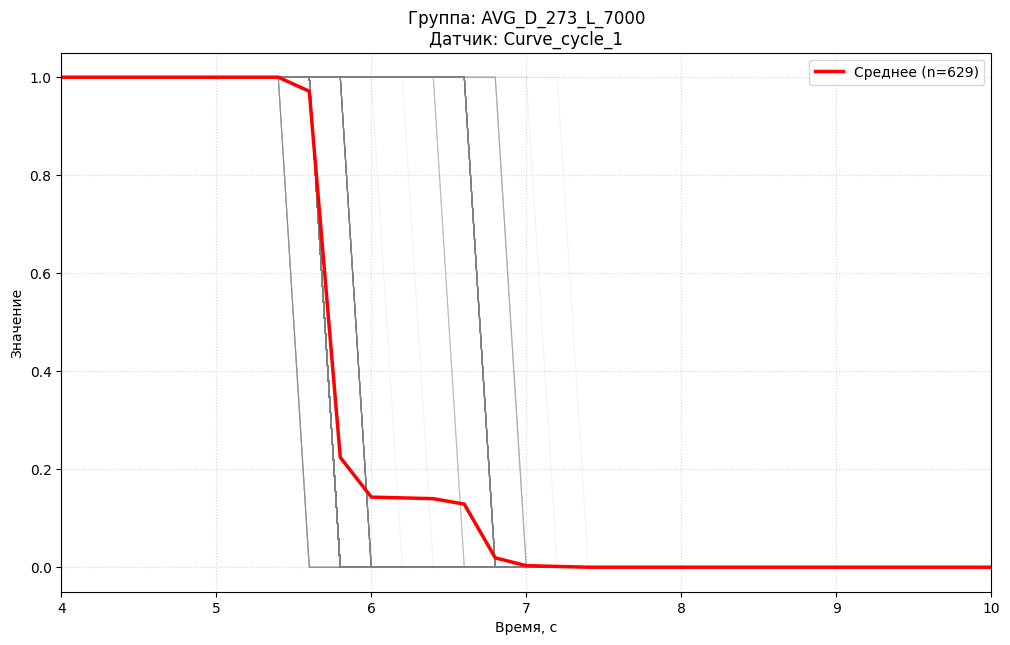

In [ ]:
sensor = "Curve_cycle_1"
pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg_p.GRAF_RESALTS_DIR)
plt.xlim(4, 10)

(-20.0, 10.0)

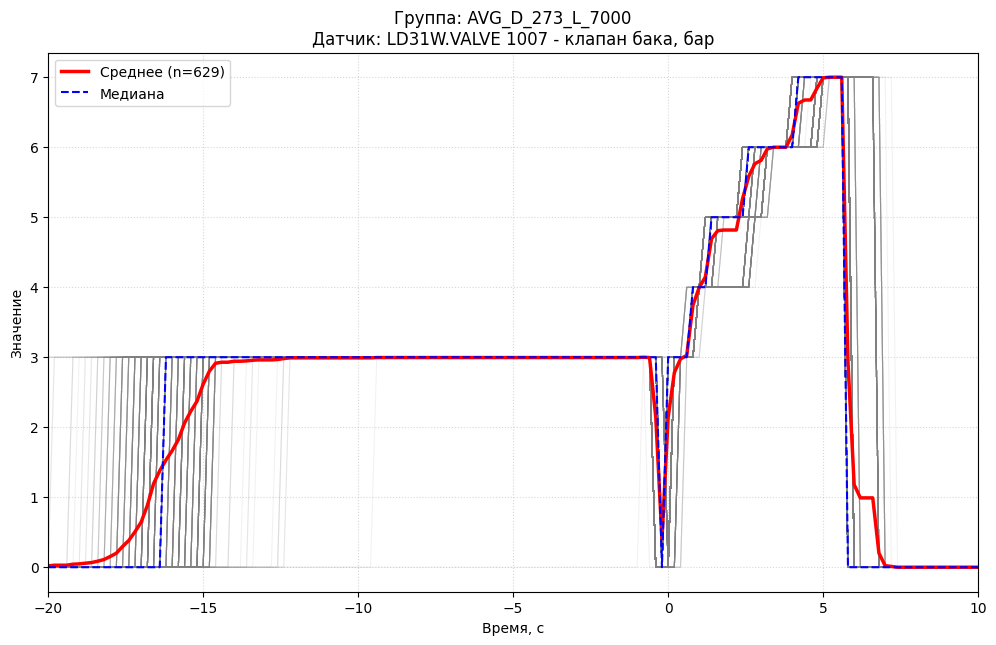

In [ ]:
sensor = "LD31W.VALVE 1007 - клапан бака, бар"
pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg_p.GRAF_RESALTS_DIR)
plt.xlim(-20, 10)

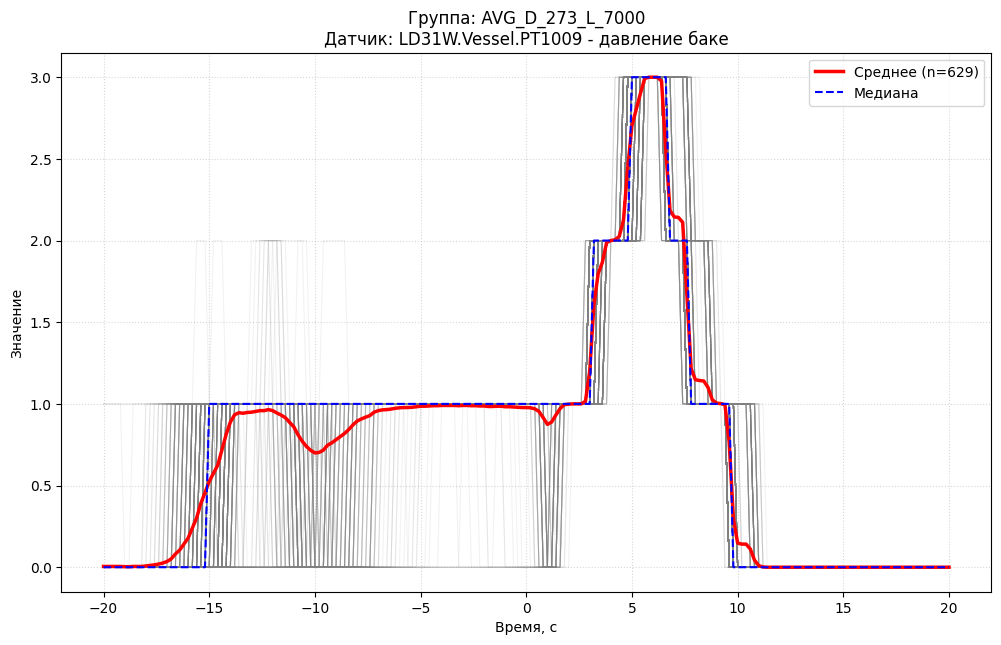

In [ ]:
sensor = "LD31W.Vessel.PT1009 - давление баке"

pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg_p.GRAF_RESALTS_DIR)

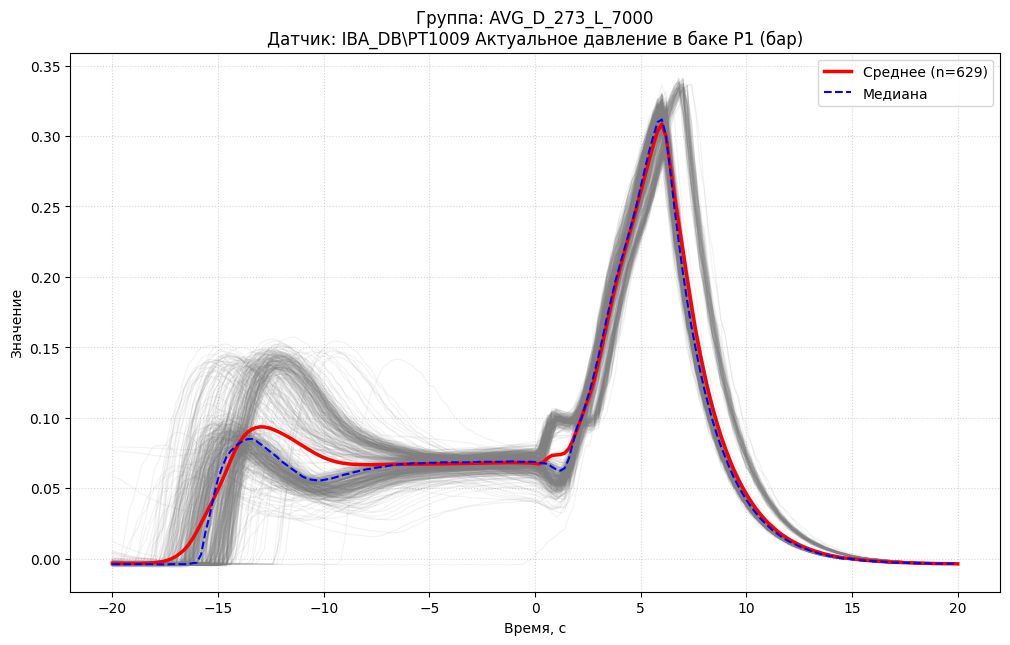

In [ ]:
sensor = "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)"
pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg_p.GRAF_RESALTS_DIR)

(-20.0, 10.0)

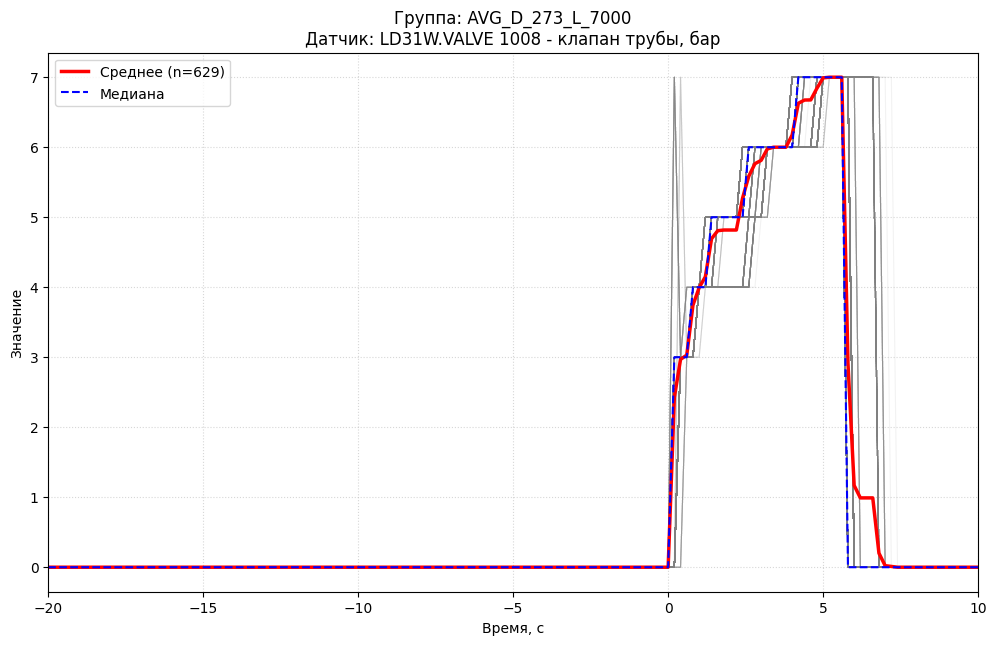

In [ ]:
sensor = "LD31W.VALVE 1008 - клапан трубы, бар"
pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg_p.GRAF_RESALTS_DIR)
plt.xlim(-20, 10)

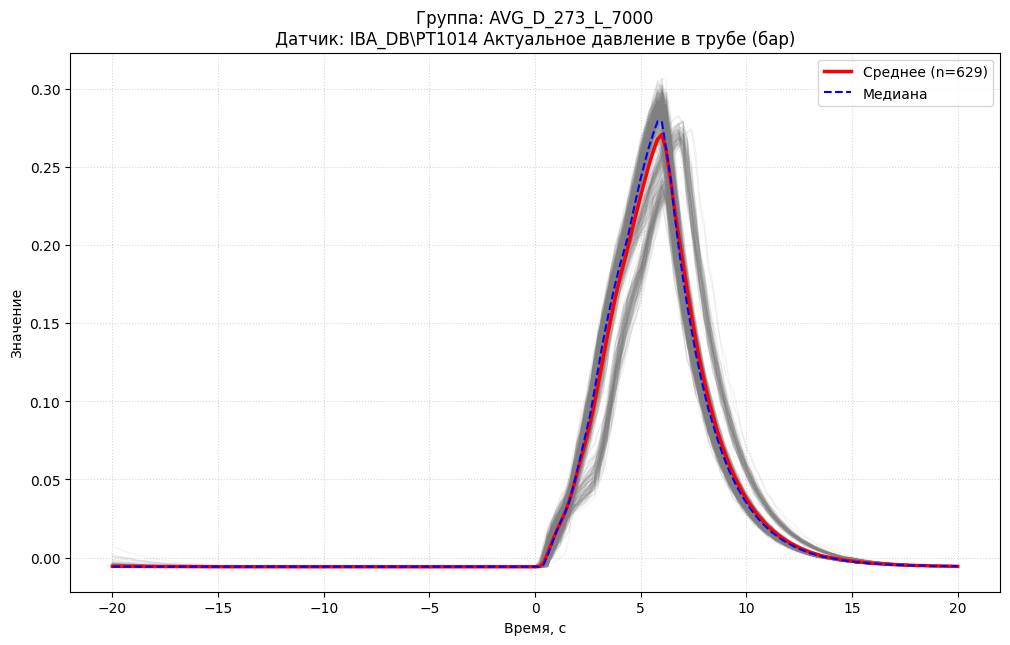

In [ ]:
sensor = "IBA_DB\PT1014 Актуальное давление в трубе (бар)"
pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg_p.GRAF_RESALTS_DIR)

(-5.0, 10.0)

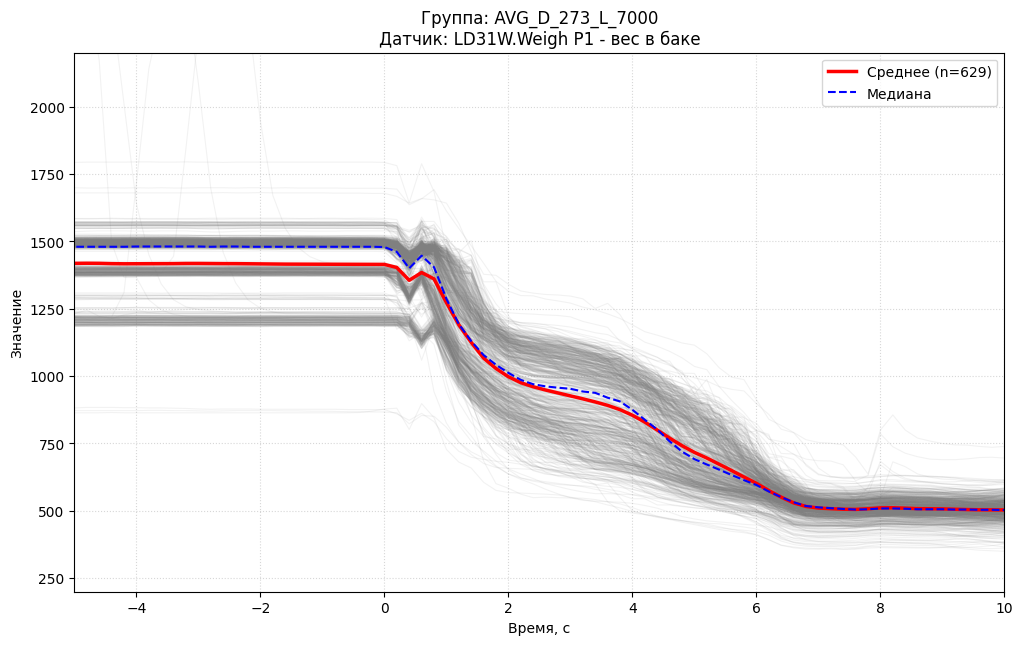

In [ ]:
sensor = "LD31W.Weigh P1 - вес в баке"

pm.plot_group_diagnostics(
    df_logs, df_registry, 
    df_avg_logs, 
    avg_id, 
    sensor, 
    cnfg.CLASSIFICATION_TASKS,
    cnfg_p.GRAF_RESALTS_DIR)
plt.ylim(200, 2200)
plt.xlim(-5, 10)
